# F1 Data Science: Technological Evolution & 2026 Prediction
## Analiza postępu technicznego w Formule 1
Projekt skupiający się na wpływie technicznych innowacji na osiągi, niezawodność i strukturę rywalizacji F1.

In [11]:
%matplotlib inline
#
# Ładowanie csv do duckdb
#
import duckdb
import kagglehub
import glob
import os
import pandas as pd

race_data  = kagglehub.dataset_download("jtrotman/formula-1-race-data")
event_data = kagglehub.dataset_download("jtrotman/formula-1-race-events")

conn = duckdb.connect("f1.db")

# Załaduj każdy CSV jako osobną tabelę
for f in glob.glob(f"{race_data}/*.csv"):
    name = os.path.splitext(os.path.basename(f))[0]
    conn.execute(f"""
        CREATE OR REPLACE TABLE {name} 
        AS SELECT * FROM read_csv_auto('{f}', null_padding=True,
            nullstr='\\N',
            sample_size=-1)
    """)
    print(f"✓ {name}")

# Events osobno
for f in glob.glob(f"{event_data}/*.csv"):
    name = "ev_" + os.path.splitext(os.path.basename(f))[0]
    conn.execute(f"""
        CREATE OR REPLACE TABLE {name}
        AS SELECT * FROM read_csv_auto('{f}', null_padding=True,
            nullstr='\\N',
            sample_size=-1)
    """)

conn.execute("SHOW TABLES").df()
conn.close()

✓ circuits
✓ constructor_results
✓ constructor_standings
✓ constructors
✓ driver_standings
✓ drivers
✓ lap_times
✓ pit_stops
✓ qualifying
✓ races
✓ results
✓ seasons
✓ sprint_results
✓ status


## 1. Strategiczne "Under-fueling" i Wpływ Paliwa na Lap Time
**Metoda**: Analiza zmian lap times przed zakazem refuelingu (do 2009) vs po zakazie (2010+)  
**Cel**: Pokazanie przyrostu prędkości w zależności od poziomu paliwa w baku (ciężaru pojazdu)

✓ Analiza jednego toru: Silverstone Circuit
  - Liczba wyścigów: 33

  === ERA Z REFUELINGIEM (1994-2009) ===
  - Liczba okrążeń: 15525

  === ERA BEZ REFUELINGU (2010+) ===
  - Liczba okrążeń: 14040

  === PROGRESJA LAP TIMES W WYŚCIGU ===

  Silverstone Circuit - ERA ZA REFUELINGIEM (1994-2009):
  - Lap 1: 97.95s
  - Ostatnie okrążenie: 93.83s
  - Różnica (Lap 1 vs Last): 4.12s

  Silverstone Circuit - ERA BEZ REFUELINGU (2010+):
  - Lap 1: 104.63s
  - Ostatnie okrążenie: 94.83s
  - Różnica (Lap 1 vs Last): 9.80s
  → POSTĘP TECHNICZNY: Teams nauczyły się minimalizować wpływ paliwa!


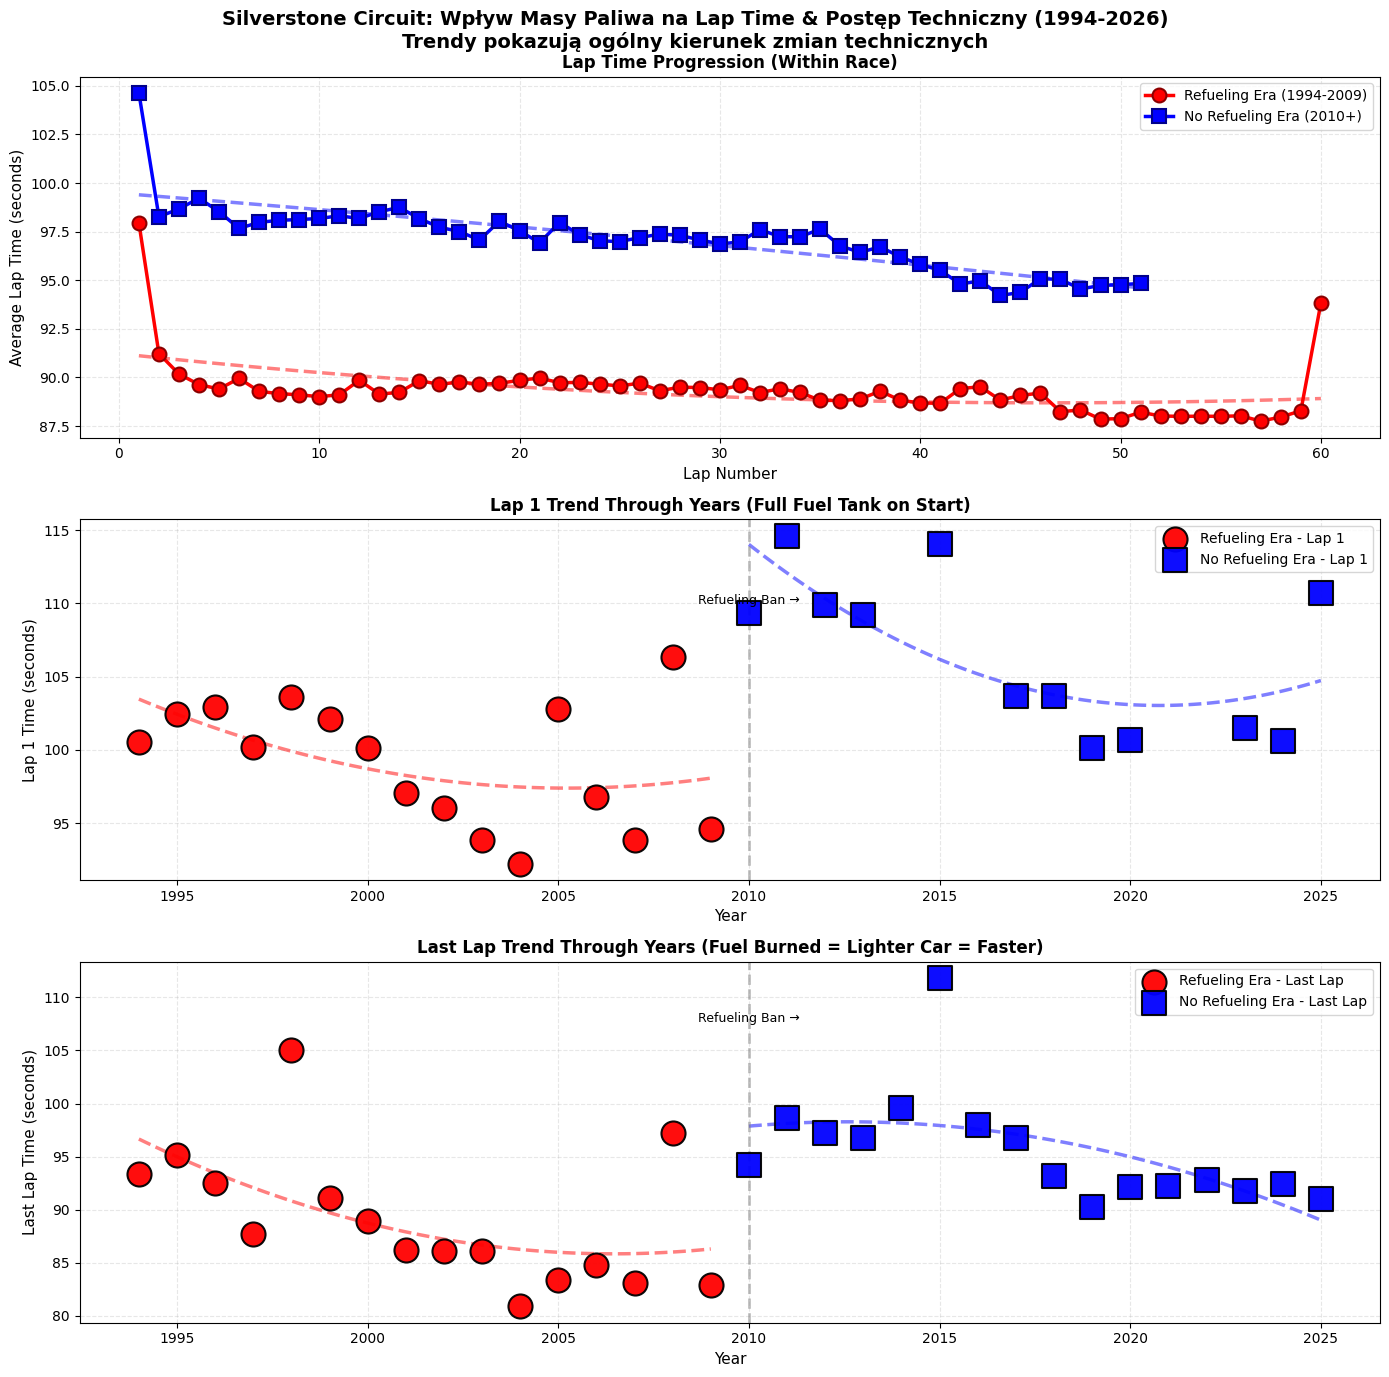


✓ Wizualizacja zapisana: f1_fuel_impact_Silverstone_Circuit.png
  -- Linie trendu = wielomian 2-go stopnia pokazujący kierunek zmian


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.polynomial import Polynomial

# === Analiza Lap Times vs Paliwo - JEDEN TÓR ===
# Porównanie: jak zmienia się lap time od pierwszego do ostatniego okrążenia
# Era z refuelingiem (1994-2009) vs bez refuelingu (2010+)

conn_laptime = duckdb.connect("f1.db")

# Pobierz lap times z informacjami o torach
lap_times_raw = conn_laptime.execute("""
    SELECT lt.raceId, lt.driverId, lt.lap, lt.milliseconds,
           EXTRACT(YEAR FROM r.date) as year, c.name as circuit_name,
           MAX(lt.lap) OVER (PARTITION BY lt.raceId) as max_lap_in_race,
           r.date as race_date
    FROM lap_times lt
    LEFT JOIN races r ON lt.raceId = r.raceId
    LEFT JOIN circuits c ON r.circuitId = c.circuitId
    WHERE lt.milliseconds IS NOT NULL AND r.year >= 1994
""").df()

conn_laptime.close()

lap_times_raw['lap_time_sec'] = lap_times_raw['milliseconds'] / 1000
lap_times_raw['refueling_era'] = (lap_times_raw['year'] < 2010).astype(int)

# Znajdź tor z największą liczbą wyścigów
circuit_race_count = lap_times_raw.groupby('circuit_name')['raceId'].nunique().sort_values(ascending=False)
selected_circuit = circuit_race_count.index[0]

print(f"✓ Analiza jednego toru: {selected_circuit}")
print(f"  - Liczba wyścigów: {circuit_race_count.iloc[0]}")

# Filtruj dane dla wybranego toru
circuit_data = lap_times_raw[lap_times_raw['circuit_name'] == selected_circuit].copy()

# Usuń outlacje/formacyjne (ostatnia okrętka) - ale ZACHOWAJ lap 1
circuit_data = circuit_data[circuit_data['lap'] < circuit_data['max_lap_in_race']].copy()

# Filtruj outliers na podstawie IQR
for era in [0, 1]:
    era_mask = circuit_data['refueling_era'] == era
    Q1 = circuit_data.loc[era_mask, 'lap_time_sec'].quantile(0.25)
    Q3 = circuit_data.loc[era_mask, 'lap_time_sec'].quantile(0.75)
    IQR = Q3 - Q1
    circuit_data = circuit_data[~(era_mask & 
                                  ((circuit_data['lap_time_sec'] < Q1 - 1.5*IQR) | 
                                   (circuit_data['lap_time_sec'] > Q3 + 1.5*IQR)))]

# Podziel na dwie ery
refuel_data = circuit_data[circuit_data['refueling_era'] == 1].copy()  # 1994-2009
no_refuel_data = circuit_data[circuit_data['refueling_era'] == 0].copy()  # 2010+

print(f"\n  === ERA Z REFUELINGIEM (1994-2009) ===")
print(f"  - Liczba okrążeń: {len(refuel_data)}")

print(f"\n  === ERA BEZ REFUELINGU (2010+) ===")
print(f"  - Liczba okrążeń: {len(no_refuel_data)}")

# Oblicz średnie czasy dla każdej pozycji okrążenia (lap 1, 2, 3, ... N)
def get_lap_progression(data):
    """Zwróć średnie czasy dla każdego numeru okrążenia"""
    avg_by_lap = data.groupby('lap').agg({
        'lap_time_sec': ['mean', 'count']
    }).reset_index().sort_values('lap')
    avg_by_lap.columns = ['lap', 'lap_time_sec', 'count']
    
    # Filtruj laps z mało danymi (< 10 samples)
    avg_by_lap = avg_by_lap[avg_by_lap['count'] >= 10]
    
    return avg_by_lap

refuel_progression = get_lap_progression(refuel_data)
no_refuel_progression = get_lap_progression(no_refuel_data)

# Analiza trendów dla lap 1 przez lata
refuel_lap1_trend = refuel_data[refuel_data['lap'] == 1].groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
refuel_lap1_trend = refuel_lap1_trend[refuel_lap1_trend['count'] >= 1]

no_refuel_lap1_trend = no_refuel_data[no_refuel_data['lap'] == 1].groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
no_refuel_lap1_trend = no_refuel_lap1_trend[no_refuel_lap1_trend['count'] >= 1]

# Ostatnie okrążenie - prawidłowo: max lap dla każdego wyścigu
refuel_race_max_lap = refuel_data.groupby('raceId')['lap'].max().reset_index()
refuel_race_max_lap.columns = ['raceId', 'max_lap']
refuel_last_lap = refuel_data.merge(refuel_race_max_lap, on='raceId')
refuel_last_lap = refuel_last_lap[refuel_last_lap['lap'] == refuel_last_lap['max_lap']]
refuel_last_lap_trend = refuel_last_lap.groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
refuel_last_lap_trend = refuel_last_lap_trend[refuel_last_lap_trend['count'] >= 3]

no_refuel_race_max_lap = no_refuel_data.groupby('raceId')['lap'].max().reset_index()
no_refuel_race_max_lap.columns = ['raceId', 'max_lap']
no_refuel_last_lap = no_refuel_data.merge(no_refuel_race_max_lap, on='raceId')
no_refuel_last_lap = no_refuel_last_lap[no_refuel_last_lap['lap'] == no_refuel_last_lap['max_lap']]
no_refuel_last_lap_trend = no_refuel_last_lap.groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
no_refuel_last_lap_trend = no_refuel_last_lap_trend[no_refuel_last_lap_trend['count'] >= 3]

print(f"\n  === PROGRESJA LAP TIMES W WYŚCIGU ===")
print(f"\n  {selected_circuit} - ERA ZA REFUELINGIEM (1994-2009):")
if len(refuel_progression) > 0:
    print(f"  - Lap 1: {refuel_progression['lap_time_sec'].iloc[0]:.2f}s")
    print(f"  - Ostatnie okrążenie: {refuel_progression['lap_time_sec'].iloc[-1]:.2f}s")
    print(f"  - Różnica (Lap 1 vs Last): {refuel_progression['lap_time_sec'].iloc[0] - refuel_progression['lap_time_sec'].iloc[-1]:.2f}s")

print(f"\n  {selected_circuit} - ERA BEZ REFUELINGU (2010+):")
if len(no_refuel_progression) > 0:
    print(f"  - Lap 1: {no_refuel_progression['lap_time_sec'].iloc[0]:.2f}s")
    print(f"  - Ostatnie okrążenie: {no_refuel_progression['lap_time_sec'].iloc[-1]:.2f}s")
    print(f"  - Różnica (Lap 1 vs Last): {no_refuel_progression['lap_time_sec'].iloc[0] - no_refuel_progression['lap_time_sec'].iloc[-1]:.2f}s")
    print(f"  → POSTĘP TECHNICZNY: Teams nauczyły się minimalizować wpływ paliwa!")

# Wizualizacja - 3 wykresy
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(f'{selected_circuit}: Wpływ Masy Paliwa na Lap Time & Postęp Techniczny (1994-2026)\nTrendy pokazują ogólny kierunek zmian technicznych', 
             fontsize=14, fontweight='bold')

# Funkcja do dodania linii trendu
def add_trend_line(ax, x, y, color, linestyle='-', alpha=0.7):
    if len(x) > 1:
        z = np.polyfit(x, y, 2)
        p = np.poly1d(z)
        x_smooth = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_smooth, p(x_smooth), linestyle=linestyle, color=color, alpha=alpha, linewidth=2.5)

# Wykres 1: Lap Progression w wyścigu (oba ery)
if len(refuel_progression) > 1:
    axes[0].plot(refuel_progression['lap'], refuel_progression['lap_time_sec'], 
                 marker='o', linewidth=2.5, color='red', label='Refueling Era (1994-2009)', markersize=10, alpha=1.0, markerfacecolor='red', markeredgecolor='darkred', markeredgewidth=1.5, zorder=3)
    add_trend_line(axes[0], refuel_progression['lap'].values, refuel_progression['lap_time_sec'].values, 'red', linestyle='--', alpha=0.5)

if len(no_refuel_progression) > 1:
    axes[0].plot(no_refuel_progression['lap'], no_refuel_progression['lap_time_sec'], 
                 marker='s', linewidth=2.5, color='blue', label='No Refueling Era (2010+)', markersize=10, alpha=1.0, markerfacecolor='blue', markeredgecolor='darkblue', markeredgewidth=1.5, zorder=3)
    add_trend_line(axes[0], no_refuel_progression['lap'].values, no_refuel_progression['lap_time_sec'].values, 'blue', linestyle='--', alpha=0.5)
    
axes[0].set_xlabel('Lap Number', fontsize=11)
axes[0].set_ylabel('Average Lap Time (seconds)', fontsize=11)
axes[0].set_title('Lap Time Progression (Within Race)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend(fontsize=10, loc='best')

# Wykres 2: Trend Lap 1 (przez lata)
if len(refuel_lap1_trend) > 0:
    axes[1].scatter(refuel_lap1_trend['year'], refuel_lap1_trend['mean'], 
                    marker='o', color='red', s=300, alpha=0.95, edgecolors='black', linewidth=1.5, label='Refueling Era - Lap 1', zorder=3)
    
    # Trend line dla refuel
    x_ref = refuel_lap1_trend['year'].values
    y_ref = refuel_lap1_trend['mean'].values
    add_trend_line(axes[1], x_ref, y_ref, 'red', linestyle='--', alpha=0.5)

if len(no_refuel_lap1_trend) > 0:
    axes[1].scatter(no_refuel_lap1_trend['year'], no_refuel_lap1_trend['mean'], 
                    marker='s', color='blue', s=300, alpha=0.95, edgecolors='black', linewidth=1.5, label='No Refueling Era - Lap 1', zorder=3)
    
    # Trend line dla no-refuel
    x_noref = no_refuel_lap1_trend['year'].values
    y_noref = no_refuel_lap1_trend['mean'].values
    add_trend_line(axes[1], x_noref, y_noref, 'blue', linestyle='--', alpha=0.5)

axes[1].axvline(x=2010, color='gray', linestyle='--', alpha=0.5, linewidth=2)
axes[1].text(2010, axes[1].get_ylim()[1]*0.95, 'Refueling Ban →', fontsize=9, ha='center')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Lap 1 Time (seconds)', fontsize=11)
axes[1].set_title('Lap 1 Trend Through Years (Full Fuel Tank on Start)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=10, loc='best')

# Wykres 3: Trend Last Lap (przez lata)
if len(refuel_last_lap_trend) > 0:
    axes[2].scatter(refuel_last_lap_trend['year'], refuel_last_lap_trend['mean'], 
                    marker='o', color='red', s=300, alpha=0.95, edgecolors='black', linewidth=1.5, label='Refueling Era - Last Lap', zorder=3)
    
    # Trend line dla refuel
    x_ref = refuel_last_lap_trend['year'].values
    y_ref = refuel_last_lap_trend['mean'].values
    add_trend_line(axes[2], x_ref, y_ref, 'red', linestyle='--', alpha=0.5)

if len(no_refuel_last_lap_trend) > 0:
    axes[2].scatter(no_refuel_last_lap_trend['year'], no_refuel_last_lap_trend['mean'], 
                    marker='s', color='blue', s=300, alpha=0.95, edgecolors='black', linewidth=1.5, label='No Refueling Era - Last Lap', zorder=3)
    
    # Trend line dla no-refuel
    x_noref = no_refuel_last_lap_trend['year'].values
    y_noref = no_refuel_last_lap_trend['mean'].values
    add_trend_line(axes[2], x_noref, y_noref, 'blue', linestyle='--', alpha=0.5)

axes[2].axvline(x=2010, color='gray', linestyle='--', alpha=0.5, linewidth=2)
axes[2].text(2010, axes[2].get_ylim()[1]*0.95, 'Refueling Ban →', fontsize=9, ha='center')
axes[2].set_xlabel('Year', fontsize=11)
axes[2].set_ylabel('Last Lap Time (seconds)', fontsize=11)
axes[2].set_title('Last Lap Trend Through Years (Fuel Burned = Lighter Car = Faster)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig(f'f1_fuel_impact_{selected_circuit.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Wizualizacja zapisana: f1_fuel_impact_{selected_circuit.replace(' ', '_')}.png")
print(f"  -- Linie trendu = wielomian 2-go stopnia pokazujący kierunek zmian")

# Dla kompatybilności z dalszym kodem
pit_strategy = pd.DataFrame()
fuel_impact_data = circuit_data.copy()

## 2. Analiza Paliwa - Drugi Tor Historyczny (1995-2026)
**Metoda**: Ta sama analiza lap times vs paliwo dla innego toru z długą historią  
**Cel**: Pokazanie czy efekt paliwa i postęp techniczny widać konsystentnie na różnych torach


✓ Tory jeżdżone od ~1998 do 2015+ (min. 3000 okrążeń):
                      circuit_name  first_year  last_year  total_laps
24                     Hungaroring        1994       2025       41774
17               Circuit de Monaco        1994       2025       40068
7       Autódromo José Carlos Pace        1994       2025       37922
16  Circuit de Barcelona-Catalunya        1994       2025       37230
13       Circuit Gilles Villeneuve        1994       2025       35131
38             Silverstone Circuit        1994       2025       32890
4     Autodromo Nazionale di Monza        1994       2025       29998
40                  Suzuka Circuit        1994       2026       27254
1   Albert Park Grand Prix Circuit        1996       2026       26776
35                   Red Bull Ring        1997       2025       25776
19    Circuit de Spa-Francorchamps        1994       2025       22270
23                  Hockenheimring        1994       2019       20119
2    Autodromo Enzo e Dino Ferrari 

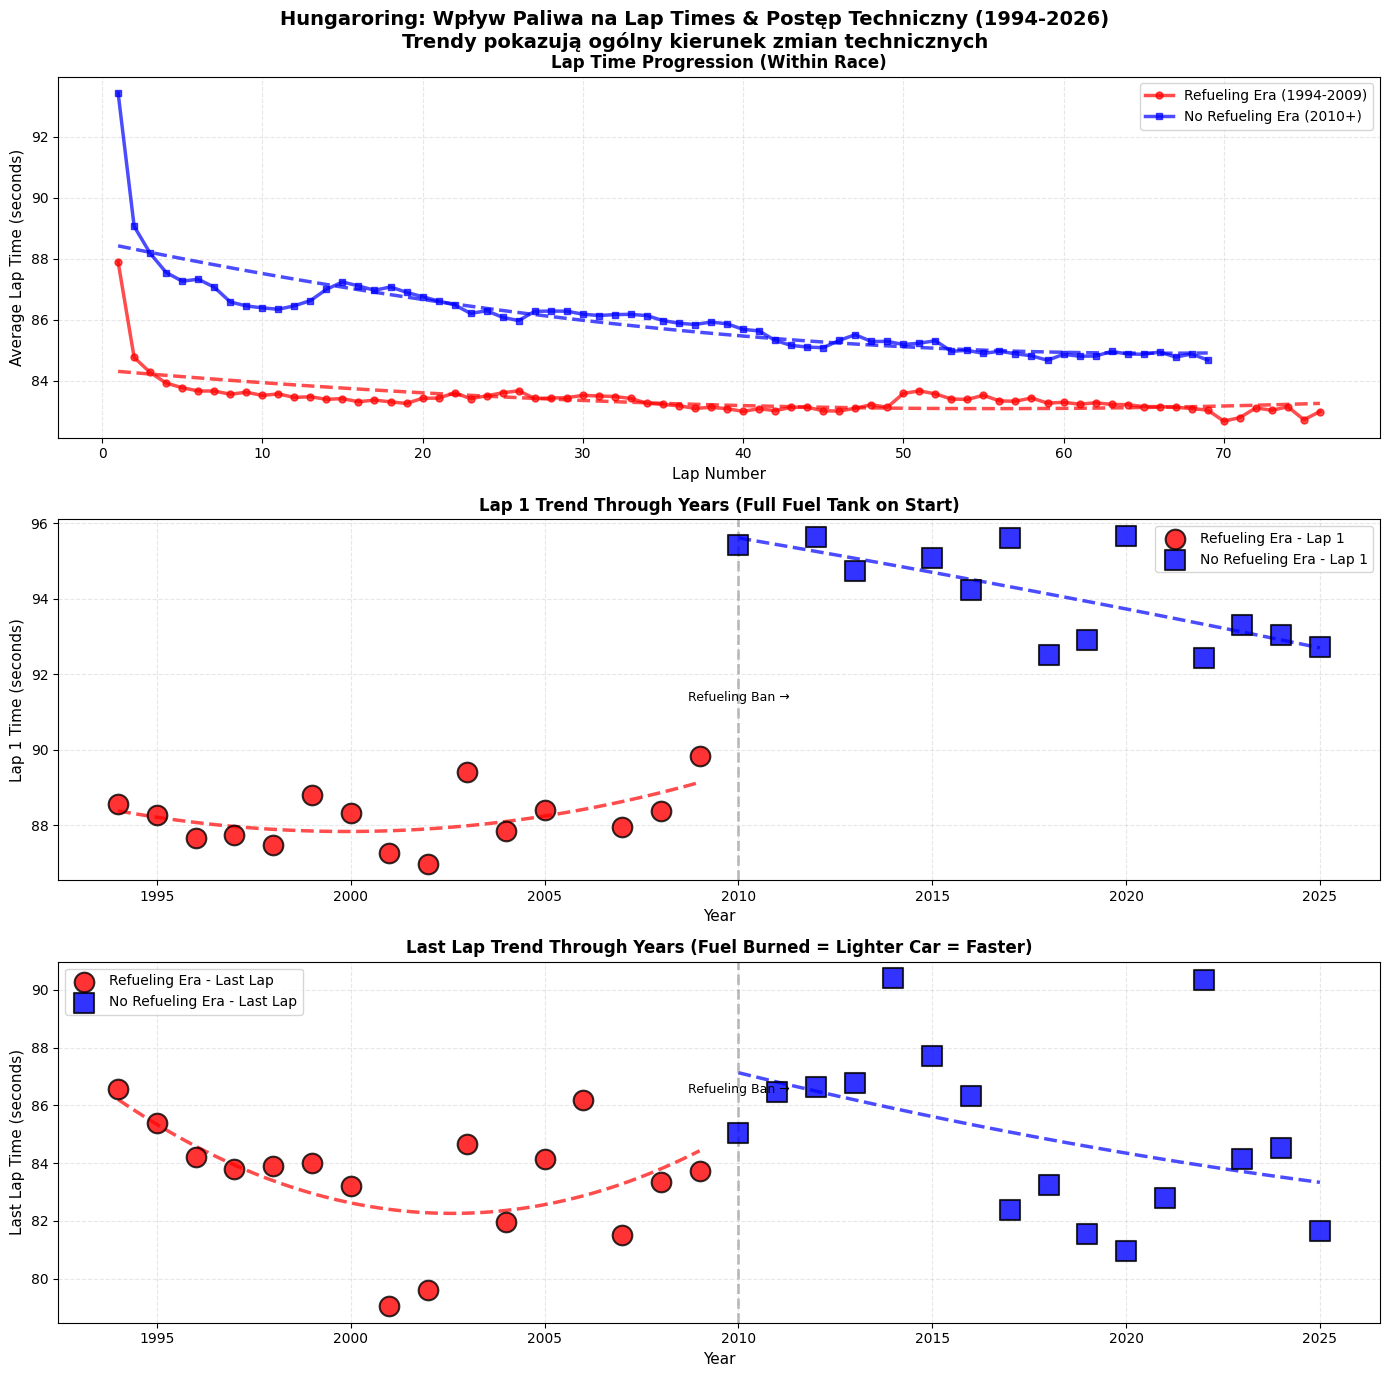


✓ Wizualizacja zapisana: f1_fuel_impact_Hungaroring.png
  -- Porównanie: Silverstone Circuit vs Hungaroring pokazuje konsystentny efekt paliwa


In [13]:
# === Analiza drugiego toru z okresu 1995-2026 ===

# Identyfikuj tory które są jeżdżone od 1995 do teraz
circuits_by_year = lap_times_raw.groupby('circuit_name')['year'].agg(['min', 'max', 'count']).reset_index()
circuits_by_year.columns = ['circuit_name', 'first_year', 'last_year', 'total_laps']

# Filtry: od 1990-ego do 2015+, z dużą ilością okrążeń
historic_circuits = circuits_by_year[
    (circuits_by_year['first_year'] <= 1998) & 
    (circuits_by_year['last_year'] >= 2015) &
    (circuits_by_year['total_laps'] >= 3000)
].sort_values('total_laps', ascending=False)

print(f"✓ Tory jeżdżone od ~1998 do 2015+ (min. 3000 okrążeń):")
print(historic_circuits[['circuit_name', 'first_year', 'last_year', 'total_laps']])

# Wybierz drugi co do wielkości tor (nie Silverstone)
historic_circuits_filtered = historic_circuits[historic_circuits['circuit_name'] != selected_circuit]
if len(historic_circuits_filtered) > 0:
    second_circuit = historic_circuits_filtered.iloc[0]['circuit_name']
    print(f"\n► Wybrany tor do analizy: {second_circuit}")
else:
    # Fallback - weź drugi co do liczby wyścigów
    second_circuit = historic_circuits.iloc[1]['circuit_name'] if len(historic_circuits) > 1 else None
    print(f"► Fallback: {second_circuit}")

if second_circuit:
    # Filtruj dane dla drugiego toru
    circuit_data_2 = lap_times_raw[lap_times_raw['circuit_name'] == second_circuit].copy()
    circuit_data_2 = circuit_data_2[circuit_data_2['lap'] < circuit_data_2['max_lap_in_race']].copy()
    
    # Filtruj outliers na podstawie IQR
    for era in [0, 1]:
        era_mask = circuit_data_2['refueling_era'] == era
        if era_mask.sum() > 0:
            Q1 = circuit_data_2.loc[era_mask, 'lap_time_sec'].quantile(0.25)
            Q3 = circuit_data_2.loc[era_mask, 'lap_time_sec'].quantile(0.75)
            IQR = Q3 - Q1
            circuit_data_2 = circuit_data_2[~(era_mask & 
                                              ((circuit_data_2['lap_time_sec'] < Q1 - 1.5*IQR) | 
                                               (circuit_data_2['lap_time_sec'] > Q3 + 1.5*IQR)))]
    
    # Podziel na ery
    refuel_data_2 = circuit_data_2[circuit_data_2['refueling_era'] == 1].copy()
    no_refuel_data_2 = circuit_data_2[circuit_data_2['refueling_era'] == 0].copy()
    
    print(f"\n  === {second_circuit.upper()} ===")
    print(f"  Era z refuelingiem (1994-2009): {len(refuel_data_2)} okrążeń")
    print(f"  Era bez refuelingu (2010+): {len(no_refuel_data_2)} okrążeń")
    
    # Oblicz progresję
    refuel_progression_2 = get_lap_progression(refuel_data_2)
    no_refuel_progression_2 = get_lap_progression(no_refuel_data_2)
    
    # Trendy przez lata
    refuel_lap1_trend_2 = refuel_data_2[refuel_data_2['lap'] == 1].groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
    refuel_lap1_trend_2 = refuel_lap1_trend_2[refuel_lap1_trend_2['count'] >= 1]
    
    no_refuel_lap1_trend_2 = no_refuel_data_2[no_refuel_data_2['lap'] == 1].groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
    no_refuel_lap1_trend_2 = no_refuel_lap1_trend_2[no_refuel_lap1_trend_2['count'] >= 1]
    
    # Ostatnie okrążenie
    refuel_race_max_lap_2 = refuel_data_2.groupby('raceId')['lap'].max().reset_index()
    refuel_race_max_lap_2.columns = ['raceId', 'max_lap']
    refuel_last_lap_2 = refuel_data_2.merge(refuel_race_max_lap_2, on='raceId')
    refuel_last_lap_2 = refuel_last_lap_2[refuel_last_lap_2['lap'] == refuel_last_lap_2['max_lap']]
    refuel_last_lap_trend_2 = refuel_last_lap_2.groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
    refuel_last_lap_trend_2 = refuel_last_lap_trend_2[refuel_last_lap_trend_2['count'] >= 3]
    
    no_refuel_race_max_lap_2 = no_refuel_data_2.groupby('raceId')['lap'].max().reset_index()
    no_refuel_race_max_lap_2.columns = ['raceId', 'max_lap']
    no_refuel_last_lap_2 = no_refuel_data_2.merge(no_refuel_race_max_lap_2, on='raceId')
    no_refuel_last_lap_2 = no_refuel_last_lap_2[no_refuel_last_lap_2['lap'] == no_refuel_last_lap_2['max_lap']]
    no_refuel_last_lap_trend_2 = no_refuel_last_lap_2.groupby('year')['lap_time_sec'].agg(['mean', 'count']).reset_index()
    no_refuel_last_lap_trend_2 = no_refuel_last_lap_trend_2[no_refuel_last_lap_trend_2['count'] >= 3]
    
    print(f"\n  === PROGRESJA LAP TIMES ===")
    if len(refuel_progression_2) > 0:
        print(f"  Era z refuelingiem (1994-2009):")
        print(f"    - Lap 1: {refuel_progression_2['lap_time_sec'].iloc[0]:.2f}s")
        print(f"    - Ostatnie okrążenie: {refuel_progression_2['lap_time_sec'].iloc[-1]:.2f}s")
        print(f"    - Różnica: {refuel_progression_2['lap_time_sec'].iloc[0] - refuel_progression_2['lap_time_sec'].iloc[-1]:.2f}s")
    
    if len(no_refuel_progression_2) > 0:
        print(f"  Era bez refuelingu (2010+):")
        print(f"    - Lap 1: {no_refuel_progression_2['lap_time_sec'].iloc[0]:.2f}s")
        print(f"    - Ostatnie okrążenie: {no_refuel_progression_2['lap_time_sec'].iloc[-1]:.2f}s")
        print(f"    - Różnica: {no_refuel_progression_2['lap_time_sec'].iloc[0] - no_refuel_progression_2['lap_time_sec'].iloc[-1]:.2f}s")
    
    # Wizualizacja - 3 wykresy
    fig2, axes2 = plt.subplots(3, 1, figsize=(14, 14))
    fig2.suptitle(f'{second_circuit}: Wpływ Paliwa na Lap Times & Postęp Techniczny (1994-2026)\nTrendy pokazują ogólny kierunek zmian technicznych', 
                 fontsize=14, fontweight='bold')
    
    # Wykres 1: Lap Progression
    if len(refuel_progression_2) > 1:
        axes2[0].plot(refuel_progression_2['lap'], refuel_progression_2['lap_time_sec'], 
                     marker='o', linewidth=2.5, color='red', label='Refueling Era (1994-2009)', markersize=5, alpha=0.7)
        add_trend_line(axes2[0], refuel_progression_2['lap'].values, refuel_progression_2['lap_time_sec'].values, 'red', linestyle='--')
    
    if len(no_refuel_progression_2) > 1:
        axes2[0].plot(no_refuel_progression_2['lap'], no_refuel_progression_2['lap_time_sec'], 
                     marker='s', linewidth=2.5, color='blue', label='No Refueling Era (2010+)', markersize=5, alpha=0.7)
        add_trend_line(axes2[0], no_refuel_progression_2['lap'].values, no_refuel_progression_2['lap_time_sec'].values, 'blue', linestyle='--')
    
    axes2[0].set_xlabel('Lap Number', fontsize=11)
    axes2[0].set_ylabel('Average Lap Time (seconds)', fontsize=11)
    axes2[0].set_title('Lap Time Progression (Within Race)', fontsize=12, fontweight='bold')
    axes2[0].grid(True, alpha=0.3, linestyle='--')
    axes2[0].legend(fontsize=10, loc='best')
    
    # Wykres 2: Lap 1 Yearly Trend
    if len(refuel_lap1_trend_2) > 0:
        axes2[1].scatter(refuel_lap1_trend_2['year'], refuel_lap1_trend_2['mean'], 
                        marker='o', color='red', s=200, alpha=0.8, edgecolors='black', linewidth=1.5, label='Refueling Era - Lap 1', zorder=3)
        x_ref = refuel_lap1_trend_2['year'].values
        y_ref = refuel_lap1_trend_2['mean'].values
        add_trend_line(axes2[1], x_ref, y_ref, 'red', linestyle='--')
    
    if len(no_refuel_lap1_trend_2) > 0:
        axes2[1].scatter(no_refuel_lap1_trend_2['year'], no_refuel_lap1_trend_2['mean'], 
                        marker='s', color='blue', s=200, alpha=0.8, edgecolors='black', linewidth=1.5, label='No Refueling Era - Lap 1', zorder=3)
        x_noref = no_refuel_lap1_trend_2['year'].values
        y_noref = no_refuel_lap1_trend_2['mean'].values
        add_trend_line(axes2[1], x_noref, y_noref, 'blue', linestyle='--')
    
    axes2[1].axvline(x=2010, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    axes2[1].text(2010, axes2[1].get_ylim()[1]*0.95, 'Refueling Ban →', fontsize=9, ha='center')
    axes2[1].set_xlabel('Year', fontsize=11)
    axes2[1].set_ylabel('Lap 1 Time (seconds)', fontsize=11)
    axes2[1].set_title('Lap 1 Trend Through Years (Full Fuel Tank on Start)', fontsize=12, fontweight='bold')
    axes2[1].grid(True, alpha=0.3, linestyle='--')
    axes2[1].legend(fontsize=10, loc='best')
    
    # Wykres 3: Last Lap Yearly Trend
    if len(refuel_last_lap_trend_2) > 0:
        axes2[2].scatter(refuel_last_lap_trend_2['year'], refuel_last_lap_trend_2['mean'], 
                        marker='o', color='red', s=200, alpha=0.8, edgecolors='black', linewidth=1.5, label='Refueling Era - Last Lap', zorder=3)
        x_ref = refuel_last_lap_trend_2['year'].values
        y_ref = refuel_last_lap_trend_2['mean'].values
        add_trend_line(axes2[2], x_ref, y_ref, 'red', linestyle='--')
    
    if len(no_refuel_last_lap_trend_2) > 0:
        axes2[2].scatter(no_refuel_last_lap_trend_2['year'], no_refuel_last_lap_trend_2['mean'], 
                        marker='s', color='blue', s=200, alpha=0.8, edgecolors='black', linewidth=1.5, label='No Refueling Era - Last Lap', zorder=3)
        x_noref = no_refuel_last_lap_trend_2['year'].values
        y_noref = no_refuel_last_lap_trend_2['mean'].values
        add_trend_line(axes2[2], x_noref, y_noref, 'blue', linestyle='--')
    
    axes2[2].axvline(x=2010, color='gray', linestyle='--', alpha=0.5, linewidth=2)
    axes2[2].text(2010, axes2[2].get_ylim()[1]*0.95, 'Refueling Ban →', fontsize=9, ha='center')
    axes2[2].set_xlabel('Year', fontsize=11)
    axes2[2].set_ylabel('Last Lap Time (seconds)', fontsize=11)
    axes2[2].set_title('Last Lap Trend Through Years (Fuel Burned = Lighter Car = Faster)', fontsize=12, fontweight='bold')
    axes2[2].grid(True, alpha=0.3, linestyle='--')
    axes2[2].legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.savefig(f'f1_fuel_impact_{second_circuit.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Wizualizacja zapisana: f1_fuel_impact_{second_circuit.replace(' ', '_')}.png")
    print(f"  -- Porównanie: {selected_circuit} vs {second_circuit} pokazuje konsystentny efekt paliwa")


## 3. "Efficiency Gap" – Dominacja technologiczna zespołów
**Metoda**: Analiza wskaźnika Supertimes (%)  
**Cel**: Statystyczny pomiar 'rozwarstwienia' stawki i identyfikacja okresów największej przewagi technicznej

✓ Analiza dominacji punktowej Top 3 zespołów:
    year  top_3_percentage
72  2022         77.520071
73  2023         68.108831
74  2024         71.264838
75  2025         66.377888
76  2026         79.702970


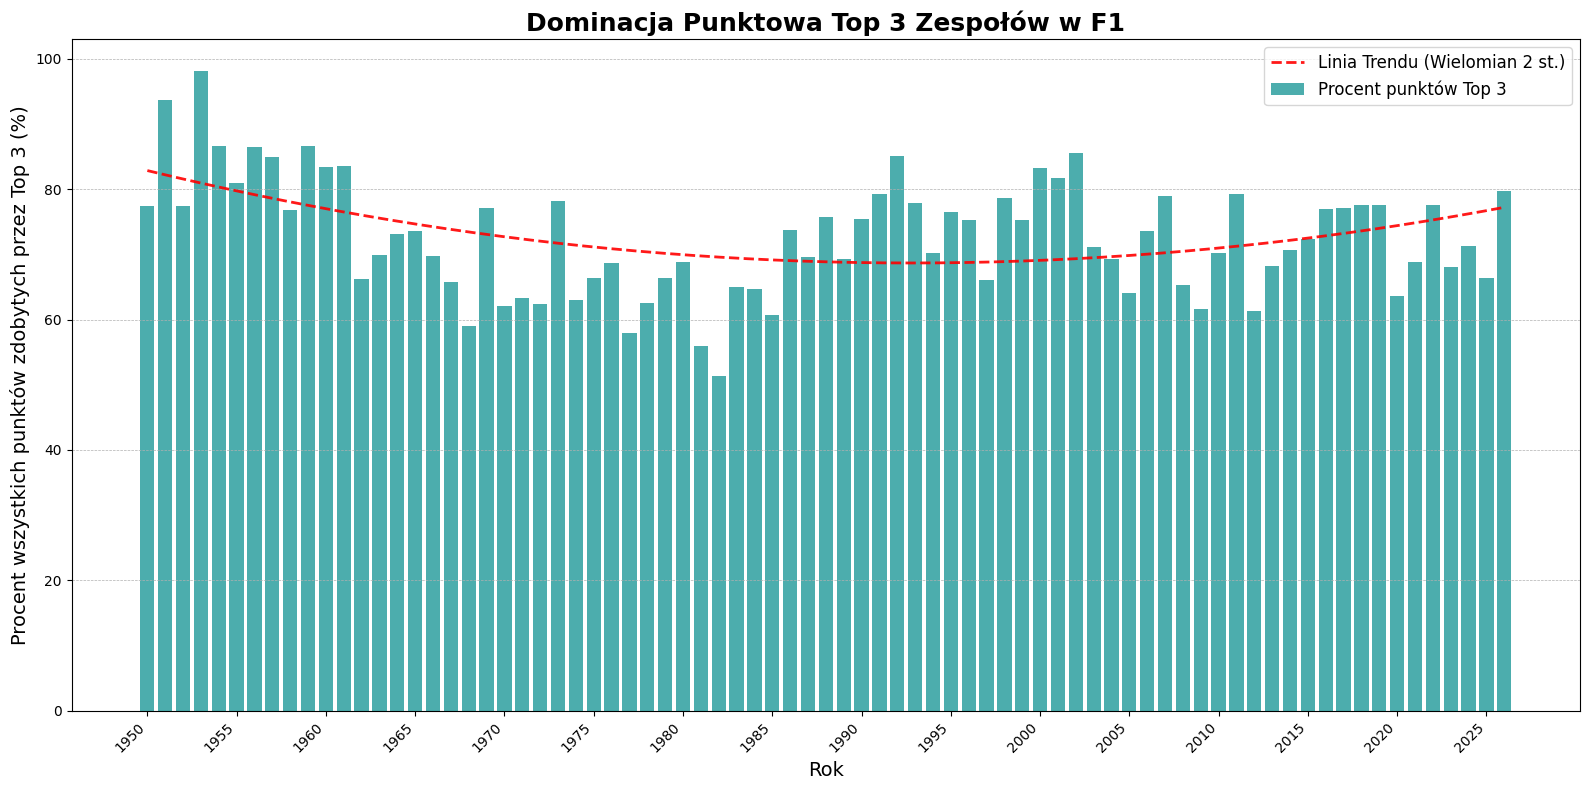

In [14]:
# Analiza "Efficiency Gap" – Dominacja Punktowa Top 3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conn = duckdb.connect("f1.db")

# Pobierz wyniki, aby zsumować punkty dla każdego konstruktora w każdym sezonie
constructor_points_per_year = conn.execute("""
    SELECT 
        r.year,
        c.name as constructor_name,
        SUM(res.points) as total_points
    FROM results res
    JOIN races r ON res.raceId = r.raceId
    JOIN constructors c ON res.constructorId = c.constructorId
    GROUP BY r.year, c.name
    ORDER BY r.year, total_points DESC
""").df()

conn.close()

# Oblicz dominację Top 3 w każdym roku
dominance_data = []
for year in sorted(constructor_points_per_year['year'].unique()):
    year_data = constructor_points_per_year[constructor_points_per_year['year'] == year].sort_values('total_points', ascending=False)
    
    if len(year_data) > 3:
        top_3_points = year_data.head(3)['total_points'].sum()
        total_points = year_data['total_points'].sum()
        
        if total_points > 0:
            top_3_percentage = (top_3_points / total_points) * 100
            
            dominance_data.append({
                'year': year,
                'top_3_percentage': top_3_percentage
            })

dominance_df = pd.DataFrame(dominance_data)

print("✓ Analiza dominacji punktowej Top 3 zespołów:")
print(dominance_df.tail())

# Wizualizacja - Poprawiony wykres główny
plt.figure(figsize=(16, 8))

# Wykres słupkowy
plt.bar(dominance_df['year'], dominance_df['top_3_percentage'], color='darkcyan', alpha=0.7, label='Procent punktów Top 3')

# Linia trendu
if len(dominance_df) > 1:
    z = np.polyfit(dominance_df['year'], dominance_df['top_3_percentage'], 2)
    p = np.poly1d(z)
    # Rysuj linię trendu na podstawie lat z danych, aby uniknąć ekstrapolacji poza zakres
    years_for_trend = np.linspace(dominance_df['year'].min(), dominance_df['year'].max(), 200)
    plt.plot(years_for_trend, p(years_for_trend), "r--", alpha=0.9, linewidth=2, label="Linia Trendu (Wielomian 2 st.)")

plt.title('Dominacja Punktowa Top 3 Zespołów w F1', fontsize=18, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Procent wszystkich punktów zdobytych przez Top 3 (%)', fontsize=14)
plt.xticks(np.arange(min(dominance_df['year']), max(dominance_df['year'])+1, 5), rotation=45, ha='right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('f1_top3_dominance_main.png', dpi=150)
plt.show()

# Zaktualizuj zmienną dla komórki podsumowującej
efficiency_gap = dominance_df.copy()

## 4. Analiza "Niezawodności Technologii" (Reliability Analysis)
**Metoda**: Eksploracyjna analiza danych (EDA) - DNF (Did Not Finish)  
**Cel**: Ilościowy dowód na postęp inżynieryjny poprzez spadek awaryjności podzespołów

✓ Reliability Analysis: 27326 wyników
  - DNF Rate (średnia): 37.37%
  - Trend: 19.32% (najnowszy rok) vs 48.75% (najstarszy)
✓ Wykres zapisany: f1_dnf_reliability.png


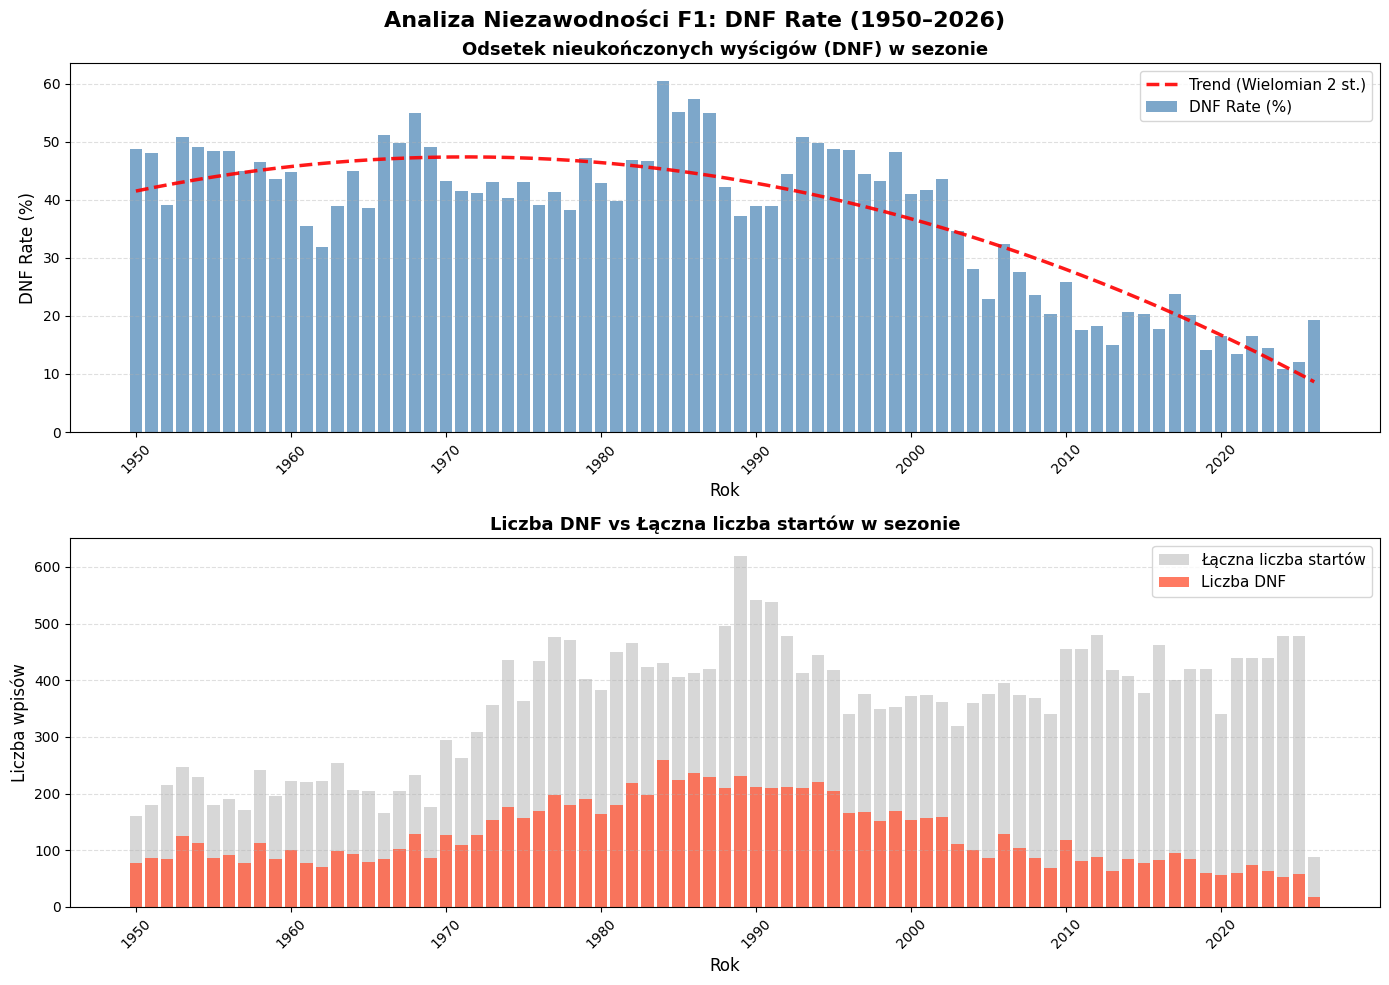

In [15]:
# Analiza niezawodności - DNF Analysis
conn = duckdb.connect("f1.db")

results = conn.execute("""
    SELECT r.raceId, res.driverId, res.constructorId, res.statusId, res.laps,
           EXTRACT(YEAR FROM r.date) as year, r.name as race_name
    FROM results res
    LEFT JOIN races r ON res.raceId = r.raceId
    LEFT JOIN status s ON res.statusId = s.statusId
    ORDER BY r.date DESC
""").df()

# DNF Rate - Define DNF as non-finished races (statusId != 1)
finished_status_ids = [1,11,12,13,14,15,16,17,18,19,45,50,128,53,55,58,88,111,112,113,114,115,116,117,118,119,120,122,123,124,125,127,133,134,97,96,92,90,81,77,62,54]

dnf_analysis = (results
    .assign(is_dnf = ~results['statusId'].isin(finished_status_ids))
    .groupby('year')
    .agg({
        'is_dnf': ['sum', 'count'],
        'laps': 'mean'
    })
    .reset_index())

dnf_analysis.columns = ['year', 'dnf_count', 'total_races', 'avg_laps_completed']
dnf_analysis['dnf_rate'] = (dnf_analysis['dnf_count'] / dnf_analysis['total_races'] * 100)

# Przyczyny DNF - jeśli dostępne
status_dnf = conn.execute("""
    SELECT s.statusId, s.status, res.statusId as used_statusId
    FROM status s
    LEFT JOIN results res ON s.statusId = res.statusId
    WHERE res.statusId NOT IN (1,11,12,13,14,15,16,17,18,19,45,50,128,53,55,58,88,111,112,113,114,115,116,117,118,119,120,122,123,124,125,127,133,134,97,96,92,90,81,77,62,54)
    GROUP BY s.statusId, s.status, res.statusId
    ORDER BY COUNT(*) DESC
""").df()

conn.close()

print(f"✓ Reliability Analysis: {len(results)} wyników")
print(f"  - DNF Rate (średnia): {dnf_analysis['dnf_rate'].mean():.2f}%")
print(f"  - Trend: {dnf_analysis['dnf_rate'].iloc[-1]:.2f}% (najnowszy rok) vs {dnf_analysis['dnf_rate'].iloc[0]:.2f}% (najstarszy)")
dnf_analysis



# Wizualizacja DNF Rate przez lata
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Analiza Niezawodności F1: DNF Rate (1950–2026)', fontsize=16, fontweight='bold')

# Wykres 1: DNF Rate jako słupki z linią trendu
axes[0].bar(dnf_analysis['year'], dnf_analysis['dnf_rate'], color='steelblue', alpha=0.7, label='DNF Rate (%)')

if len(dnf_analysis) > 1:
    z = np.polyfit(dnf_analysis['year'], dnf_analysis['dnf_rate'], 2)
    p = np.poly1d(z)
    years_smooth = np.linspace(dnf_analysis['year'].min(), dnf_analysis['year'].max(), 300)
    axes[0].plot(years_smooth, p(years_smooth), 'r--', linewidth=2.5, alpha=0.9, label='Trend (Wielomian 2 st.)')

axes[0].set_xlabel('Rok', fontsize=12)
axes[0].set_ylabel('DNF Rate (%)', fontsize=12)
axes[0].set_title('Odsetek nieukończonych wyścigów (DNF) w sezonie', fontsize=13, fontweight='bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)
axes[0].legend(fontsize=11)
axes[0].set_xticks(np.arange(dnf_analysis['year'].min(), dnf_analysis['year'].max() + 1, 10))
axes[0].tick_params(axis='x', rotation=45)

# Wykres 2: Bezwzględna liczba DNF i łączna liczba startów
axes[1].bar(dnf_analysis['year'], dnf_analysis['total_races'], color='lightgray', alpha=0.9, label='Łączna liczba startów')
axes[1].bar(dnf_analysis['year'], dnf_analysis['dnf_count'], color='tomato', alpha=0.85, label='Liczba DNF')

axes[1].set_xlabel('Rok', fontsize=12)
axes[1].set_ylabel('Liczba wpisów', fontsize=12)
axes[1].set_title('Liczba DNF vs Łączna liczba startów w sezonie', fontsize=13, fontweight='bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4)
axes[1].legend(fontsize=11)
axes[1].set_xticks(np.arange(dnf_analysis['year'].min(), dnf_analysis['year'].max() + 1, 10))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('f1_dnf_reliability.png', dpi=150, bbox_inches='tight')
print("✓ Wykres zapisany: f1_dnf_reliability.png")
plt.show()

## 5. "Prawo Moore'a" w F1: Ewolucja tempa kwalifikacyjnego
**Metoda**: Analiza szeregów czasowych (Time Series)  
**Cel**: Badanie przyrostu prędkości na torach historycznych (Monza, Monaco) jako miara tempa innowacji

✓ Analiza Prawa Moore'a w F1 (Fastest Laps z lap_times): 796 wyścigów z danymi
  - Zakres lat: 1982 - 2026
   year  fastest_lap_sec
0  1982        88.588000
1  1983        93.285400
2  1984        89.687687
3  1985        88.770625
4  1986        88.611125
    year  fastest_lap_sec
40  2022        87.765500
41  2023        86.295091
42  2024        86.081083
43  2025        85.456250
44  2026        90.416750


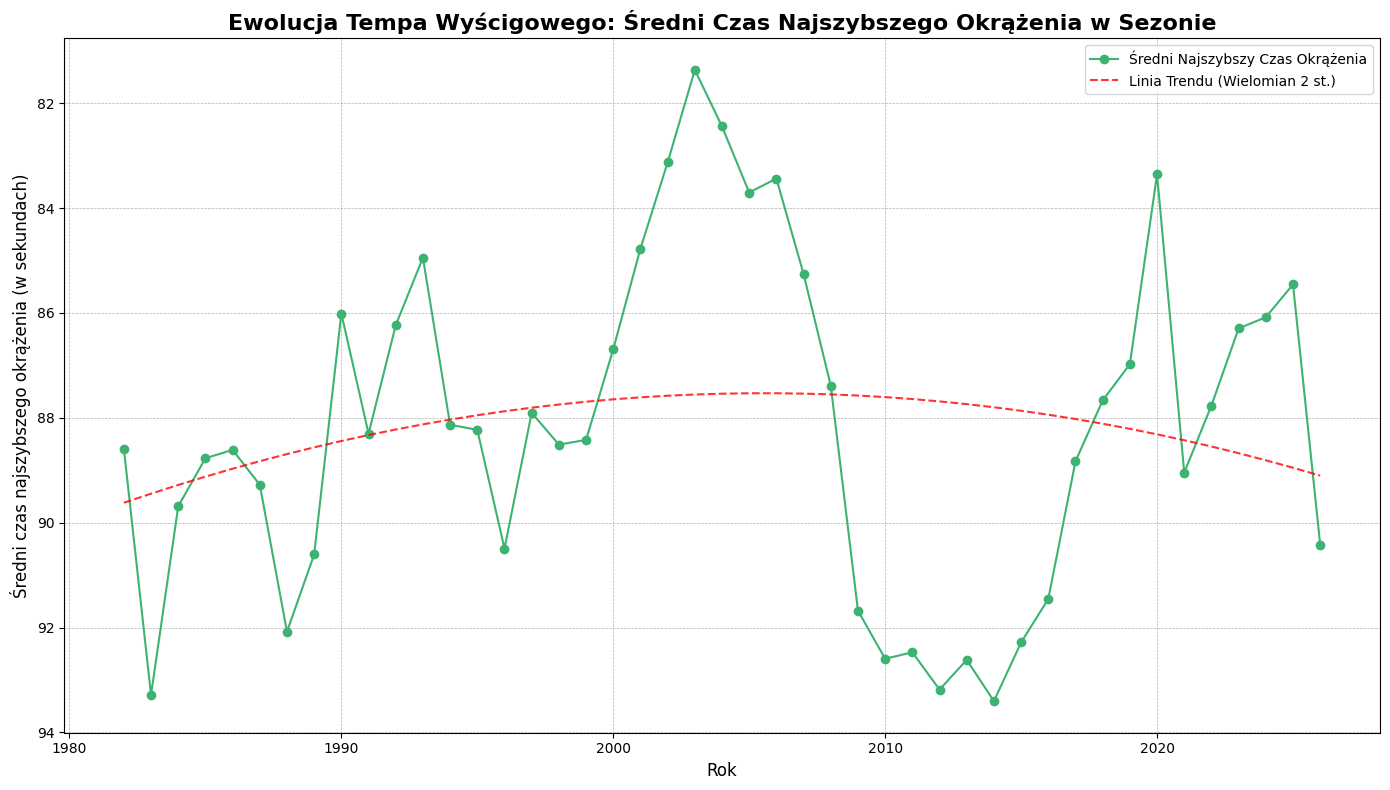

In [16]:
# Moore's Law in F1 - Analiza ewolucji najszybszych okrążeń w wyścigach (z lap_times)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

conn = duckdb.connect("f1.db")

# Pobierz najszybsze okrążenie z każdego wyścigu, korzystając z tabeli lap_times
fastest_laps_data = conn.execute("""
    WITH RaceFastestLaps AS (
        SELECT 
            r.year,
            r.raceId,
            MIN(lt.milliseconds) as fastest_lap_ms
        FROM lap_times lt
        JOIN races r ON lt.raceId = r.raceId
        WHERE lt.milliseconds IS NOT NULL
        GROUP BY r.year, r.raceId
    )
    SELECT 
        year,
        fastest_lap_ms
    FROM RaceFastestLaps
""").df()

conn.close()

# Konwertuj milisekundy na sekundy
fastest_laps_data['fastest_lap_sec'] = fastest_laps_data['fastest_lap_ms'] / 1000
fastest_laps_data = fastest_laps_data.dropna(subset=['fastest_lap_sec'])

# Oblicz średni czas najszybszego okrążenia na rok
yearly_fastest_lap_performance = fastest_laps_data.groupby('year')['fastest_lap_sec'].mean().reset_index()

print(f"✓ Analiza Prawa Moore'a w F1 (Fastest Laps z lap_times): {len(fastest_laps_data)} wyścigów z danymi")
print(f"  - Zakres lat: {yearly_fastest_lap_performance['year'].min()} - {yearly_fastest_lap_performance['year'].max()}")
print(yearly_fastest_lap_performance.head())
print(yearly_fastest_lap_performance.tail())

# Wizualizacja
plt.figure(figsize=(14, 8))
plt.plot(yearly_fastest_lap_performance['year'], yearly_fastest_lap_performance['fastest_lap_sec'], marker='o', linestyle='-', color='mediumseagreen', label='Średni Najszybszy Czas Okrążenia')

# Linia trendu
valid_data = yearly_fastest_lap_performance.dropna(subset=['year', 'fastest_lap_sec'])
if len(valid_data) > 1:
    z = np.polyfit(valid_data['year'], valid_data['fastest_lap_sec'], 2) # Wielomian 2-go stopnia
    p = np.poly1d(z)
    plt.plot(valid_data['year'], p(valid_data['year']), "r--", alpha=0.8, label="Linia Trendu (Wielomian 2 st.)")

plt.title("Ewolucja Tempa Wyścigowego: Średni Czas Najszybszego Okrążenia w Sezonie", fontsize=16, fontweight='bold')
plt.xlabel("Rok", fontsize=12)
plt.ylabel("Średni czas najszybszego okrążenia (w sekundach)", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.gca().invert_yaxis() # Odwróć oś Y, żeby postęp (krótszy czas) był widoczny jako trend rosnący
plt.legend()
plt.tight_layout()
plt.savefig('f1_moores_law_fastest_lap_from_laptimes.png', dpi=150)
plt.show()

# Zaktualizuj zmienną dla ostatniej komórki podsumowującej
yearly_performance = yearly_fastest_lap_performance.rename(columns={'fastest_lap_sec': 'avg_fastest_lap_sec'})

## Podsumowanie i Statystyka
Poniżej zbiera się wszystkie kluczowe wskaźniki do modelowania predykcyjnego 2026.

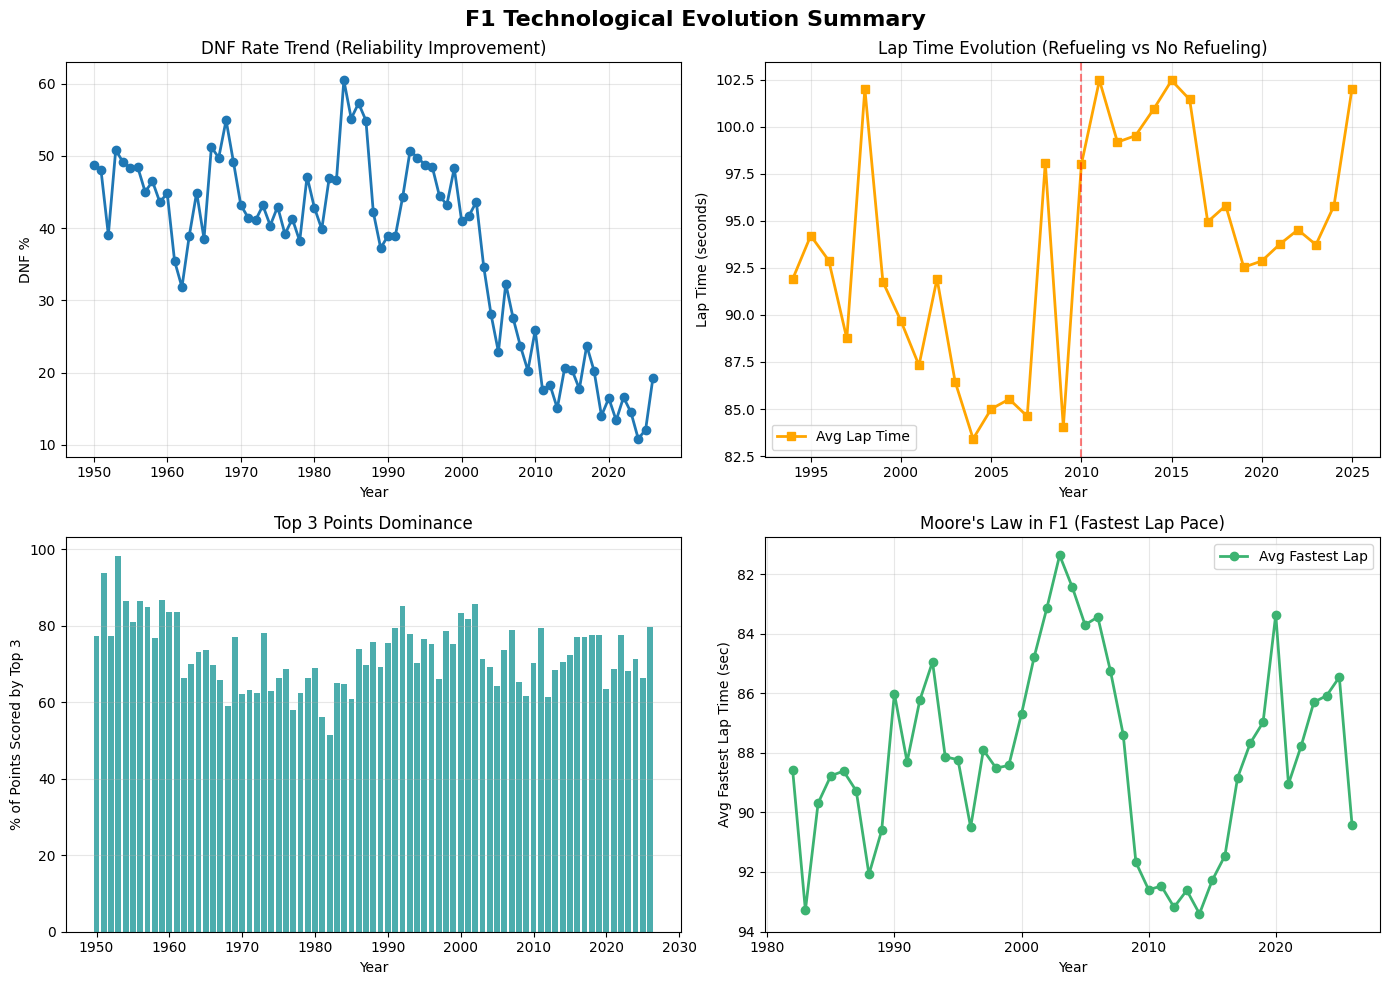


✓ Visualizations saved to 'f1_analysis_summary.png'


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Podsumowanie wskaźników
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('F1 Technological Evolution Summary', fontsize=16, fontweight='bold')

# 1. DNF Rate Trend
dnf_trend = dnf_analysis.sort_values('year')
axes[0, 0].plot(dnf_trend['year'], dnf_trend['dnf_rate'], marker='o', linewidth=2)
axes[0, 0].set_title('DNF Rate Trend (Reliability Improvement)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('DNF %')
axes[0, 0].grid(True, alpha=0.3)

# 2. Ewolucja Czasu Okrążenia
lap_time_evolution = fuel_impact_data.groupby('year')['lap_time_sec'].mean().reset_index()
lap_time_evolution = lap_time_evolution.sort_values('year')

axes[0, 1].plot(lap_time_evolution['year'], lap_time_evolution['lap_time_sec'], marker='s', label='Avg Lap Time', linewidth=2, color='orange')
axes[0, 1].set_title('Lap Time Evolution (Refueling vs No Refueling)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Lap Time (seconds)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
# Zaznacz linię 2010 (zakaz refuelingu)
axes[0, 1].axvline(x=2010, color='red', linestyle='--', alpha=0.5, label='No Refuel Ban')

# 3. Top 3 Dominance
axes[1, 0].bar(efficiency_gap['year'], efficiency_gap['top_3_percentage'], alpha=0.7, color='darkcyan')
axes[1, 0].set_title('Top 3 Points Dominance')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('% of Points Scored by Top 3')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Speed Trend - Fastest Lap from lap_times
axes[1, 1].plot(yearly_performance['year'], yearly_performance['avg_fastest_lap_sec'], marker='o', color='mediumseagreen', linewidth=2, label='Avg Fastest Lap')
axes[1, 1].set_title("Moore's Law in F1 (Fastest Lap Pace)")
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Avg Fastest Lap Time (sec)')
axes[1, 1].invert_yaxis() # Odwróć oś Y
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('f1_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations saved to 'f1_analysis_summary.png'")

## 6. Analiza Historyczna: Najlepsi Konstruktorzy Wszech Czasów
**Metoda**: Wskaźnik "Średnia liczba punktów na sezon"  
**Cel**: Identyfikacja najbardziej efektywnych i konsekwentnych zespołów w historii F1, normalizując wyniki względem liczby sezonów, w których brali udział.


✓ Top 20 Konstruktorów Wszech Czasów (wg. średniej liczby punktów na sezon):
    constructor_name  total_points  num_seasons  points_per_season
86          Mercedes       8314.64           19         437.612632
198         Red Bull       8109.00           22         368.590909
144         Lotus F1        706.00            4         176.500000
101          Ferrari      11542.27           77         149.899610
146          McLaren       7868.50           57         138.043860
125      Force India       1098.00           11          99.818182
123   Alpine F1 Team        538.00            6          89.666667
113       BMW Sauber        308.00            4          77.000000
112       AlphaTauri        306.00            4          76.500000
46           Renault       1777.00           24          74.041667
147         Williams       3770.00           51          73.921569
97      Aston Martin        572.00            8          71.500000
49          Benetton        861.50           16     

/tmp/ipykernel_3315527/3416111622.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='points_per_season', y='constructor_name', data=top_20_constructors, palette='viridis')


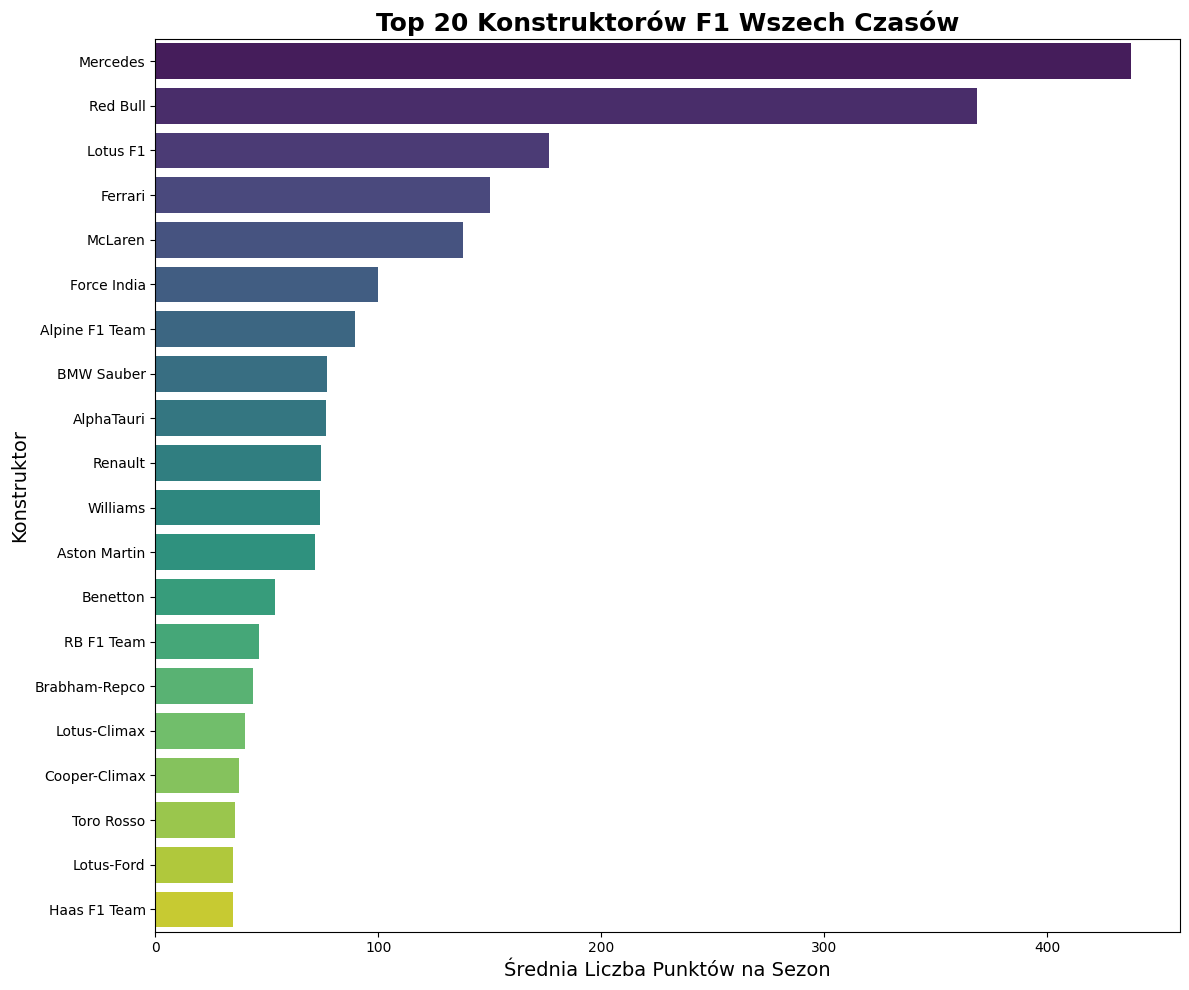

In [18]:
# Analiza "Points per Season" dla konstruktorów
import seaborn as sns

conn = duckdb.connect("f1.db")

# 1. Oblicz sumę punktów dla każdego konstruktora
constructor_total_points = conn.execute("""
    SELECT 
        c.name as constructor_name,
        SUM(res.points) as total_points
    FROM results res
    JOIN constructors c ON res.constructorId = c.constructorId
    GROUP BY c.name
""").df()

# 2. Oblicz liczbę sezonów dla każdego konstruktora
constructor_seasons = conn.execute("""
    SELECT 
        c.name as constructor_name,
        COUNT(DISTINCT r.year) as num_seasons
    FROM results res
    JOIN races r ON res.raceId = r.raceId
    JOIN constructors c ON res.constructorId = c.constructorId
    GROUP BY c.name
""").df()

conn.close()

# 3. Połącz dane i oblicz wskaźnik
constructor_performance = pd.merge(constructor_total_points, constructor_seasons, on='constructor_name')
constructor_performance['points_per_season'] = constructor_performance['total_points'] / constructor_performance['num_seasons']

# Filtruj zespoły z co najmniej 3 sezonami, aby uniknąć anomalii
constructor_performance = constructor_performance[constructor_performance['num_seasons'] >= 3]

# Sortuj i weź Top 20
top_20_constructors = constructor_performance.sort_values('points_per_season', ascending=False).head(20)

print("✓ Top 20 Konstruktorów Wszech Czasów (wg. średniej liczby punktów na sezon):")
print(top_20_constructors)

# Wizualizacja
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='points_per_season', y='constructor_name', data=top_20_constructors, palette='viridis')

plt.title('Top 20 Konstruktorów F1 Wszech Czasów', fontsize=18, fontweight='bold')
plt.xlabel('Średnia Liczba Punktów na Sezon', fontsize=14)
plt.ylabel('Konstruktor', fontsize=14)
plt.tight_layout()
plt.savefig('f1_top_constructors_by_points_per_season.png', dpi=150)
plt.show()

## 7. Indeks "Pojedynku Zespołowego": Talent vs. Pieniądze
**Metoda**: Porównanie wyników kierowców wewnątrz tego samego zespołu w kwalifikacjach i wyścigach.  
**Cel**: Identyfikacja kierowców, którzy regularnie pokonują swoich kolegów z zespołu, co może świadczyć o czystym talencie przewyższającym możliwości bolidu.


✓ Top 20 Kierowców w Wewnątrz-Zespołowych Pojedynkach (min. 50 wyścigów w parze):
               driver_name   wins  losses  total_races_in_pair  win_percentage
281         Max Verstappen  147.0    30.0                177.0       83.050847
30            Ayrton Senna   56.0    16.0                 72.0       77.777778
117        Fernando Alonso  226.0    77.0                303.0       74.587459
283     Michael Schumacher  134.0    48.0                182.0       73.626374
307             Niki Lauda   44.0    17.0                 61.0       72.131148
298          Nelson Piquet   45.0    19.0                 64.0       70.312500
132         George Russell   89.0    41.0                130.0       68.461538
58         Charles Leclerc   94.0    47.0                141.0       66.666667
287          Mika Häkkinen   43.0    24.0                 67.0       64.179104
398       Sebastian Vettel  142.0    84.0                226.0       62.831858
227     Juan Pablo Montoya   32.0    19.0        

/tmp/ipykernel_3315527/1348560363.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='win_percentage', y='driver_name', data=top_20_duelists, palette='coolwarm')


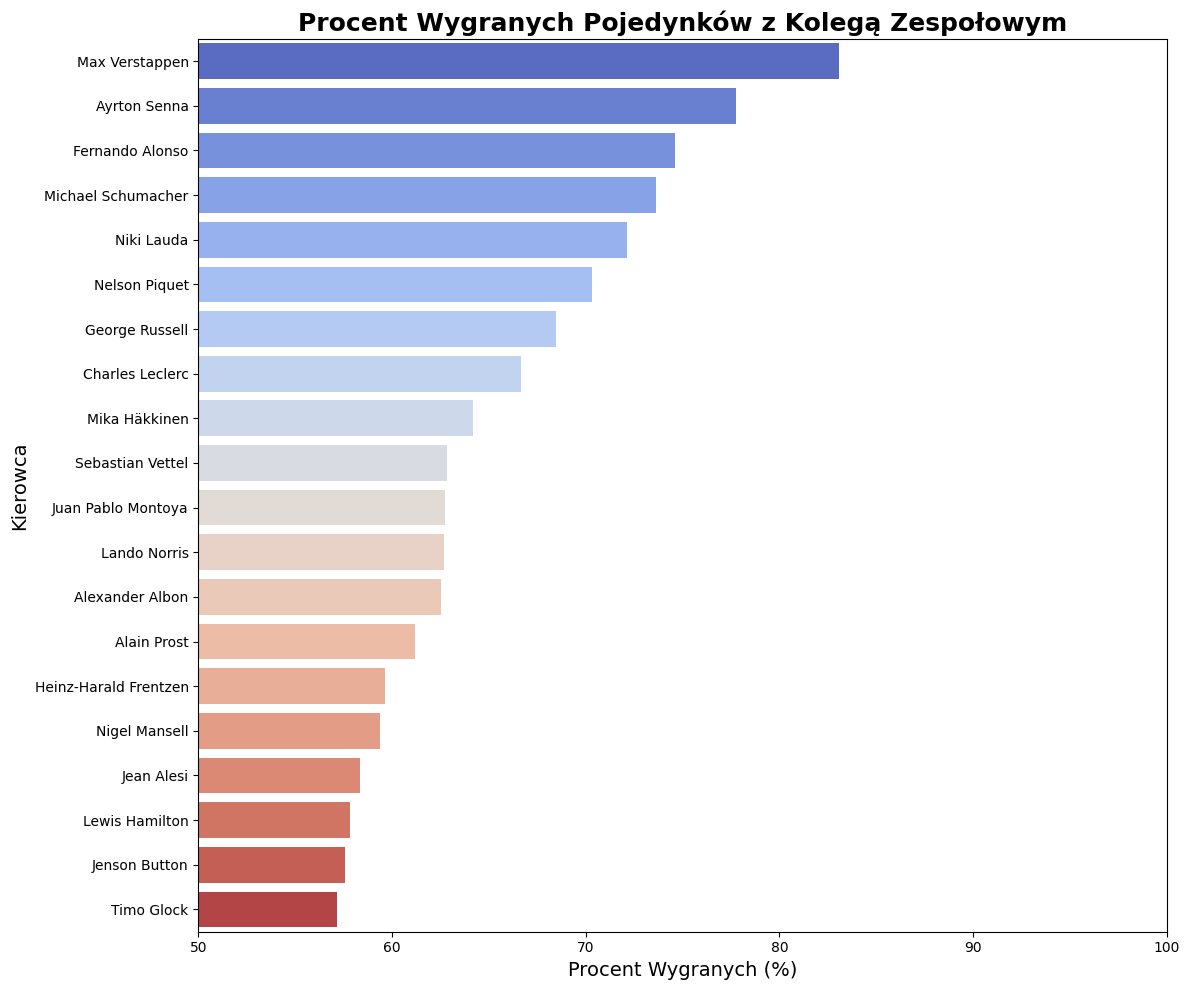

In [19]:
# Analiza pojedynków wewnątrz zespołowych
conn = duckdb.connect("f1.db")

# Pobierz wyniki wyścigów i kwalifikacji
race_results = conn.execute("""
    SELECT r.year, r.raceId, res.driverId, d.forename || ' ' || d.surname as driver_name, res.constructorId, res.position
    FROM results res
    JOIN races r ON res.raceId = r.raceId
    JOIN drivers d ON res.driverId = d.driverId
    WHERE res.position IS NOT NULL
""").df()

conn.close()

race_results['position'] = pd.to_numeric(race_results['position'], errors='coerce')
race_results.dropna(subset=['position'], inplace=True)

# Przygotuj dane do porównań
teammate_battles = []
for race_id, group in race_results.groupby('raceId'):
    for constructor_id, team_group in group.groupby('constructorId'):
        if len(team_group) == 2:
            d1 = team_group.iloc[0]
            d2 = team_group.iloc[1]
            
            # Kto wygrał?
            winner_id = d1['driverId'] if d1['position'] < d2['position'] else d2['driverId']
            loser_id = d2['driverId'] if d1['position'] < d2['position'] else d1['driverId']
            
            teammate_battles.append({'year': d1['year'], 'winnerId': winner_id, 'loserId': loser_id})

battle_df = pd.DataFrame(teammate_battles)

# Zlicz wygrane i przegrane
wins = battle_df.groupby('winnerId').size().reset_index(name='wins')
losses = battle_df.groupby('loserId').size().reset_index(name='losses')

# Połącz z nazwami kierowców
driver_names = race_results[['driverId', 'driver_name']].drop_duplicates()
wins = wins.merge(driver_names, left_on='winnerId', right_on='driverId')
losses = losses.merge(driver_names, left_on='loserId', right_on='driverId')

# Połącz wszystko w jedną ramkę danych
driver_stats = pd.merge(wins, losses, on='driver_name', how='outer').fillna(0)
driver_stats = driver_stats[['driver_name', 'wins', 'losses']]
driver_stats['total_races_in_pair'] = driver_stats['wins'] + driver_stats['losses']
driver_stats['win_percentage'] = (driver_stats['wins'] / driver_stats['total_races_in_pair']) * 100

# Filtruj kierowców z co najmniej 50 wyścigami w parze
driver_stats_filtered = driver_stats[driver_stats['total_races_in_pair'] >= 50].sort_values('win_percentage', ascending=False)

# Top 20 kierowców w pojedynkach
top_20_duelists = driver_stats_filtered.head(20)

print("✓ Top 20 Kierowców w Wewnątrz-Zespołowych Pojedynkach (min. 50 wyścigów w parze):")
print(top_20_duelists)

# Wizualizacja
plt.figure(figsize=(12, 10))
sns.barplot(x='win_percentage', y='driver_name', data=top_20_duelists, palette='coolwarm')
plt.title('Procent Wygranych Pojedynków z Kolegą Zespołowym', fontsize=18, fontweight='bold')
plt.xlabel('Procent Wygranych (%)', fontsize=14)
plt.ylabel('Kierowca', fontsize=14)
plt.xlim(50, 100) # Ogranicz oś X, żeby lepiej pokazać różnice w czołówce
plt.tight_layout()
plt.savefig('f1_teammate_duels.png', dpi=150)
plt.show()